# Create multiple extension modules to a loading module for the biosynthesis of `Basidalin`

The RetroTide repository consists of two key packages - `bcs` and `retrotide`. The `bcs` package comprises key PKS domains (e.g. AT, DH, ER, KR) and their corresponding reaction rules, written as SMARTS templates with RDKit. These domains can then be concatenated together to form modules, which can in turn be concatenated together to form a chimeric type I PKS. Meanwhile, `retrotide` calls upon `bcs` to combinatorially explore the design space of chimeric type I PKSs with the objective of synthesizing a target molecule, or at least, its required carbon scaffold.

The introduction presented here is specifically for `bcs` rather than `retrotide`. Consequently, in building various PKS designs here, we specify the various starter and extender units as well as the domain architectures within a module. When using `retrotide`, however, we only need to provide a target molecule as the input, after which `retrotide` will recursively decide on the optimal choice of starters, extenders, and domain architectures to use in order to automatically design chimeric PKSs that produce molecules which are chemically similar to the specified target.

In [2]:
from retrotide import retrotide, structureDB

In [3]:
import bcs
from collections import OrderedDict
from rdkit import Chem

In [4]:
# import image module
from IPython.display import Image

# get the image
Image(url="basidalin_biopks.png", width=600, height=300)

SMILES: O=C([S])CO


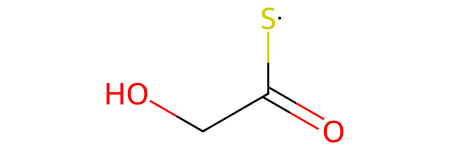

In [5]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

cluster = bcs.Cluster(modules = [loading_module])
mol = cluster.computeProduct(structureDB)

# Convert mol to SMILES
smiles = Chem.MolToSmiles(mol)
print("SMILES:", smiles)
mol

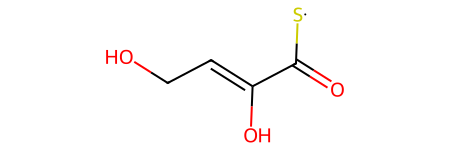

In [5]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

### first extension module with hydroxymalonyl-CoA + DH + KR domain
AT_domain_mod1 = bcs.AT(active = True, substrate = "hmal") 
KR_domain_mod1 = bcs.KR(active = True, type = "B1")
DH_domain_mod1 = bcs.DH(active = True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})

module1 = bcs.Module(domains = mod1_domains_dict, loading = False)

cluster = bcs.Cluster(modules = [loading_module, module1])
mol = cluster.computeProduct(structureDB)
mol

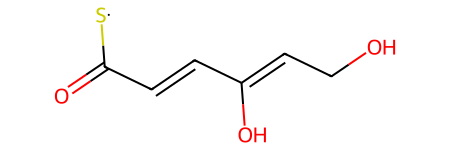

In [37]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

### first extension module with hydroxymalonyl-CoA + DH + KR domain
AT_domain_mod1 = bcs.AT(active = True, substrate = "hmal") 
KR_domain_mod1 = bcs.KR(active = True, type = "B1")
DH_domain_mod1 = bcs.DH(active = True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})

module1 = bcs.Module(domains = mod1_domains_dict, loading = False)

### second extension module with malonyl-CoA+ DH + KR domain
AT_domain_mod2 = bcs.AT(active = True, substrate = "Malonyl-CoA") 
DH_domain_mod2 = bcs.DH(active = True)
KR_domain_mod2 = bcs.KR(active = True, type = "B")
mod2_domains_dict = OrderedDict({bcs.AT: AT_domain_mod2,
                                 bcs.KR: KR_domain_mod2,
                                 bcs.DH: DH_domain_mod2,
                                 })

module2 = bcs.Module(domains = mod2_domains_dict, loading = False)

cluster = bcs.Cluster(modules = [loading_module, 
                                 module1,
                                 module2])

mol_wModule1_wModule2 = cluster.computeProduct(structureDB)
mol_wModule1_wModule2

SMILES: O=C1C=CC(=CCO)O1


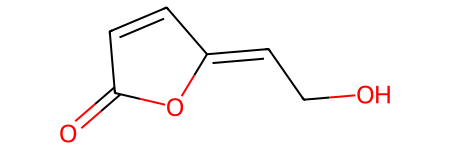

In [36]:
### add PKS release module TE
myTEobject = bcs.TE(active=True, cyclic=True, ring=1)
basidalin_mol_step1 = myTEobject.operation(mol_wModule1_wModule2)
# Convert mol to SMILES
basidalin_mol_step1_smiles = Chem.MolToSmiles(basidalin_mol_step1)
print("SMILES:", basidalin_mol_step1_smiles)
basidalin_mol_step1

### Use DORANET to construct next steps of `Basidalin`

### How to diversify `PKS` designs

In [59]:
len(structureDB)

95

In [42]:
structureDB

{["AT{'substrate': 'Methylmalonyl-CoA'}", "KR{'type': 'A1'}", 'loading: False']: <rdkit.Chem.rdchem.Mol at 0xffff3fa8d0e0>,
 ["AT{'substrate': 'emal'}", "KR{'type': 'A1'}", 'loading: False']: <rdkit.Chem.rdchem.Mol at 0xffff3f01ccf0>,
 ["AT{'substrate': 'isobutmal'}", "KR{'type': 'A2'}", 'loading: False']: <rdkit.Chem.rdchem.Mol at 0xffff3f01c7b0>,
 ["AT{'substrate': 'D-isobutmal'}", "KR{'type': 'A2'}", 'loading: False']: <rdkit.Chem.rdchem.Mol at 0xffff3f01f610>,
 ["AT{'substrate': 'hexmal'}", "KR{'type': 'B1'}", 'loading: False']: <rdkit.Chem.rdchem.Mol at 0xffff3f01c120>,
 ["AT{'substrate': 'hexmal'}", "KR{'type': 'C1'}", 'loading: False']: <rdkit.Chem.rdchem.Mol at 0xffff3f01da10>,
 ["AT{'substrate': 'butmal'}", "KR{'type': 'C1'}", 'loading: False']: <rdkit.Chem.rdchem.Mol at 0xffff3f01d070>,
 ["AT{'substrate': 'hmal'}", "KR{'type': 'C1'}", 'loading: False']: <rdkit.Chem.rdchem.Mol at 0xffff3f01eff0>,
 ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'loading: False']: <rdkit.

### Diversify molecules
1. Keep fixed starter, module1, and release module
2. diversify only second extension module

In [64]:
%%time

from rdkit import Chem
from rdkit.Chem import Descriptors
from collections import OrderedDict
import pandas as pd

# Extract Module objects from structureDB keys
allModules = list(structureDB.keys())

print("Number of uniques designs in module:", len(allModules))

results = []

print(f"\nCreating diverse molecules with fixed starter, module1, and TE...")
print(f"Varying second extension module from {len(allModules)} possibilities\n")

# Fixed components
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active=True, substrate="Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains=LM_domains_dict, loading=True)

AT_domain_mod1 = bcs.AT(active=True, substrate="hmal") 
KR_domain_mod1 = bcs.KR(active=True, type="B1")
DH_domain_mod1 = bcs.DH(active=True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})
module1 = bcs.Module(domains=mod1_domains_dict, loading=False)

myTEobject = bcs.TE(active=True, cyclic=True, ring=1)

# Create descriptions for fixed modules
starter_description = "AT(Hydroxymalonyl-CoA)"
first_extension_description = "AT(hmal) + KR(B1) + DH"
release_description = "TE(cyclic, ring=1)"

# Iterate through all possible second extension modules
for idx, module2 in enumerate(allModules):
    try:
        # Create cluster with fixed starter, module1, and variable module2
        cluster = bcs.Cluster(modules=[loading_module, module1, module2])
        mol = cluster.computeProduct(structureDB)
        
        if mol:
            # Apply TE release
            final_mol = myTEobject.operation(mol)
            
            if final_mol:
                smiles = Chem.MolToSmiles(final_mol, canonical=True)
                
                # Calculate molecular weight
                mol_obj = Chem.MolFromSmiles(smiles)
                mol_weight = Descriptors.MolWt(mol_obj) if mol_obj else None
                
                # Create description for module2
                module2_description = str(module2)
                
                results.append({
                    'Canonical_SMILES': smiles,
                    'starter_mod': starter_description,
                    'firstExtension_module': first_extension_description,
                    'secondExtension_mod': module2_description,
                    'release_mod': release_description,
                    'Molecular_Weight': round(mol_weight, 2) if mol_weight else None
                })
                
                if (idx + 1) % 10 == 0:
                    print(f"Processed {idx + 1}/{len(allModules)} modules...")
                    
    except Exception as e:
        # Print full error for debugging
        if idx < 3:
            import traceback
            print(f"\nFull error for module index {idx}:")
            traceback.print_exc()
        continue

# Create DataFrame with columns in specified order
generated_molecules_seocndExtensionOnly = pd.DataFrame(results, columns=[
    'Canonical_SMILES',
    'starter_mod',
    'firstExtension_module',
    'secondExtension_mod',
    'release_mod',
    'Molecular_Weight'
])

print(f"\nTotal molecules generated: {len(generated_molecules_seocndExtensionOnly)}")
if len(allModules) > 0:
    print(f"Success rate: {len(generated_molecules_seocndExtensionOnly)}/{len(allModules)} ({100*len(generated_molecules_seocndExtensionOnly)/len(allModules):.1f}%)")

# Drop duplicate SMILES
generated_molecules_seocndExtensionOnly = generated_molecules_seocndExtensionOnly.drop_duplicates(subset=['Canonical_SMILES'], keep='first')
print(f"\nMolecules left after removing duplicates: {len(generated_molecules_seocndExtensionOnly)}")
# Save to CSV
generated_molecules_seocndExtensionOnly.to_csv('generated_molecules_seocndExtensionOnly.csv', index=False)
print("\nSaved to 'generated_molecules_seocndExtensionOnly.csv'")
generated_molecules_seocndExtensionOnly

Number of uniques designs in module: 95

Creating diverse molecules with fixed starter, module1, and TE...
Varying second extension module from 95 possibilities

Processed 10/95 modules...
Processed 20/95 modules...
Processed 30/95 modules...
Processed 40/95 modules...
Processed 50/95 modules...
Processed 60/95 modules...
Processed 70/95 modules...
Processed 80/95 modules...
Processed 90/95 modules...

Total molecules generated: 95
Success rate: 95/95 (100.0%)

Molecules left after removing duplicates: 79

Saved to 'generated_molecules_seocndExtensionOnly.csv'
CPU times: user 84 ms, sys: 2.19 ms, total: 86.1 ms
Wall time: 83.1 ms


,Canonical_SMILES,starter_mod,firstExtension_module,secondExtension_mod,release_mod,Molecular_Weight
0,C[C@H]1C(=O)O[C@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...","TE(cyclic, ring=1)",158.15
1,CC[C@H]1C(=O)O[C@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'A1'}""...","TE(cyclic, ring=1)",172.18
2,CC(C)[C@@H]1C(=O)O[C@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'isobutmal'}"", ""KR{'type': '...","TE(cyclic, ring=1)",186.21
4,CCCCCC[C@H]1C(=O)O[C@@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'B1'...","TE(cyclic, ring=1)",228.29
5,CCCCCC[C@H]1C(=O)OC(=CCO)C1=O,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'C1'...","TE(cyclic, ring=1)",226.27
...,...,...,...,...,...,...
90,CCC1=CC(=CCO)OC1=O,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'B1'}""...","TE(cyclic, ring=1)",154.16
91,CCCC[C@H]1CC(=CCO)OC1=O,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'butmal'}"", ""KR{'type': 'B1'...","TE(cyclic, ring=1)",184.23
92,C=CCC1=CC(=CCO)OC1=O,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'allylmal'}"", ""KR{'type': 'B...","TE(cyclic, ring=1)",166.18
93,CC[C@H]1C(=O)OC(=CCO)C1=O,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'C1'}""...","TE(cyclic, ring=1)",170.16


### Display molecules

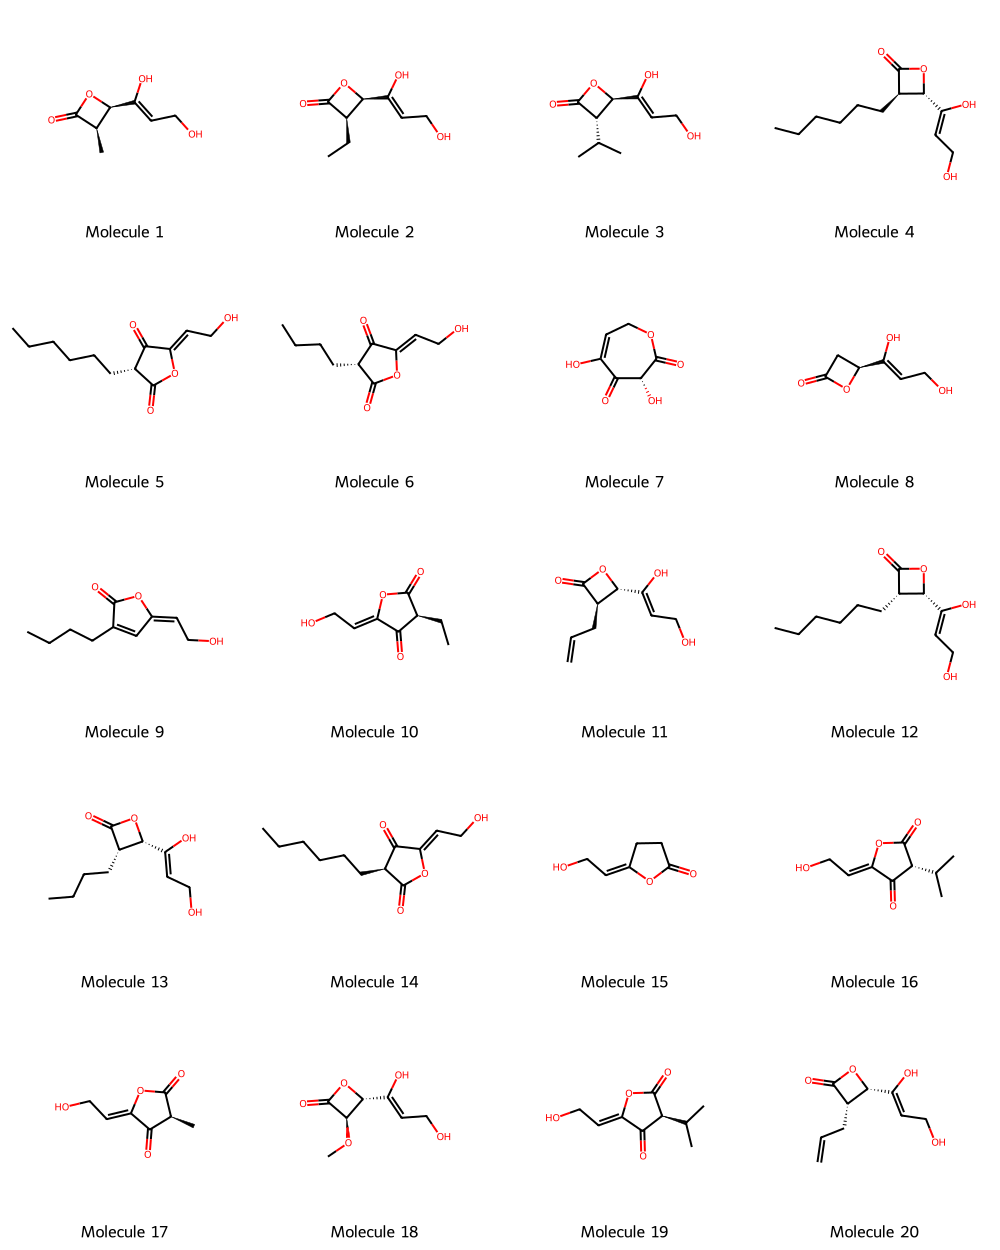

In [68]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES back to molecules for visualization
mols = [Chem.MolFromSmiles(smiles) for smiles in generated_molecules_seocndExtensionOnly['Canonical_SMILES'].head(20)]

# Create a grid of molecules
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 250),
                           legends=[f"Molecule {i+1}" for i in range(len(mols))])
display(img)

### Diversify molecules
1. Keep fixed module1 and release module
2. diversify only starter and second extension module

In [67]:
%%time

from rdkit import Chem
from rdkit.Chem import Descriptors
from collections import OrderedDict
import pandas as pd

# Extract Module objects from structureDB keys
allModules = list(structureDB.keys())

print("Number of unique designs in module:", len(allModules))
print(f"Maximum possible combinations: {len(allModules)} starters × {len(allModules)} second extensions = {len(allModules) * len(allModules)}")

results = []

# Track failures
failure_reasons = {
    'no_product_from_computeProduct': 0,
    'no_final_mol_from_TE': 0,
    'exception_errors': 0
}

print(f"\nCreating diverse molecules with variable starter and module2...")
print(f"Keeping module1 and TE fixed\n")

# Fixed components (module1 and TE only)
AT_domain_mod1 = bcs.AT(active=True, substrate="hmal") 
KR_domain_mod1 = bcs.KR(active=True, type="B1")
DH_domain_mod1 = bcs.DH(active=True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})
module1 = bcs.Module(domains=mod1_domains_dict, loading=False)

myTEobject = bcs.TE(active=True, cyclic=True, ring=1)

# Fixed descriptions
first_extension_description = "AT(hmal) + KR(B1) + DH"
release_description = "TE(cyclic, ring=1)"

# Nested loop: iterate through all starter and second extension combinations
total_combinations = len(allModules) * len(allModules)
processed = 0

for starter_idx, starter_module in enumerate(allModules):
    # Create loading module from starter_module domains
    # Force loading=True for the starter
    loading_module = bcs.Module(domains=starter_module.domains, loading=True)
    starter_description = str(starter_module)
    
    for mod2_idx, module2 in enumerate(allModules):
        processed += 1
        
        try:
            # Create cluster with variable starter, fixed module1, and variable module2
            cluster = bcs.Cluster(modules=[loading_module, module1, module2])
            mol = cluster.computeProduct(structureDB)
            
            if mol:
                # Apply TE release
                final_mol = myTEobject.operation(mol)
                
                if final_mol:
                    smiles = Chem.MolToSmiles(final_mol, canonical=True)
                    
                    # Calculate molecular weight
                    mol_obj = Chem.MolFromSmiles(smiles)
                    mol_weight = Descriptors.MolWt(mol_obj) if mol_obj else None
                    
                    # Create description for module2
                    module2_description = str(module2)
                    
                    results.append({
                        'Canonical_SMILES': smiles,
                        'starter_mod': starter_description,
                        'firstExtension_module': first_extension_description,
                        'secondExtension_mod': module2_description,
                        'release_mod': release_description,
                        'Molecular_Weight': round(mol_weight, 2) if mol_weight else None
                    })
                else:
                    # TE operation returned None
                    failure_reasons['no_final_mol_from_TE'] += 1
                    if failure_reasons['no_final_mol_from_TE'] <= 3:
                        print(f"TE failed for starter={starter_idx}, mod2={mod2_idx}")
            else:
                # computeProduct returned None
                failure_reasons['no_product_from_computeProduct'] += 1
                if failure_reasons['no_product_from_computeProduct'] <= 3:
                    print(f"computeProduct failed for starter={starter_idx}, mod2={mod2_idx}")
                    
            if processed % 1000 == 0:
                print(f"Processed {processed}/{total_combinations} combinations ({100*processed/total_combinations:.1f}%)...")
                        
        except Exception as e:
            failure_reasons['exception_errors'] += 1
            if failure_reasons['exception_errors'] <= 3:
                import traceback
                print(f"\nException for combination (starter={starter_idx}, mod2={mod2_idx}):")
                traceback.print_exc()
            continue

# Create DataFrame
generated_molecules_diverseStarterSeocndExtension = pd.DataFrame(results, columns=[
    'Canonical_SMILES',
    'starter_mod',
    'firstExtension_module',
    'secondExtension_mod',
    'release_mod',
    'Molecular_Weight'
])


print("Summary:")
print(f"Total molecules generated: {len(generated_molecules_diverseStarterSeocndExtension)}")
print(f"Success rate: {len(generated_molecules_diverseStarterSeocndExtension)}/{total_combinations} ({100*len(generated_molecules_diverseStarterSeocndExtension)/total_combinations:.1f}%)")


print("\nFailed combinations:")
successful = len(generated_molecules_diverseStarterSeocndExtension)
total_failed = total_combinations - successful

for reason, count in failure_reasons.items():
    percentage = (count/total_combinations)*100 if total_combinations > 0 else 0
    print(f"  {reason}: {count} ({percentage:.1f}%)")

print(f"\nTotal successful: {successful} ({100*successful/total_combinations:.1f}%)")
print(f"Total failed: {total_failed} ({100*total_failed/total_combinations:.1f}%)")

# Drop duplicate SMILES
original_count = len(generated_molecules_diverseStarterSeocndExtension)
generated_molecules_diverseStarterSeocndExtension = generated_molecules_diverseStarterSeocndExtension.drop_duplicates(subset=['Canonical_SMILES'], keep='first')
print(f"Molecules before deduplication: {original_count}")
print(f"Unique molecules after removing duplicates: {len(generated_molecules_diverseStarterSeocndExtension)}")
print(f"Duplicates removed: {original_count - len(generated_molecules_diverseStarterSeocndExtension)} ({100*(original_count - len(generated_molecules_diverseStarterSeocndExtension))/original_count:.1f}%)")

# Save to CSV
generated_molecules_diverseStarterSeocndExtension.to_csv('generated_molecules_diverseStarterSeocndExtension.csv', index=False)
print("\nSaved to 'generated_molecules_diverseStarterSeocndExtension.csv'")
generated_molecules_diverseStarterSeocndExtension

Number of unique designs in module: 95
Maximum possible combinations: 95 starters × 95 second extensions = 9025

Creating diverse molecules with variable starter and module2...
Keeping module1 and TE fixed


Exception for combination (starter=0, mod2=5):

Exception for combination (starter=0, mod2=6):

Exception for combination (starter=0, mod2=9):


Traceback (most recent call last):
  File "<timed exec>", line 59, in <module>
  File "/usr/local/lib/python3.12/site-packages/bcs/bcs.py", line 1135, in operation
    prod = rxn.RunReactants((chain,))[index][0]
           ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: tuple index out of range
Traceback (most recent call last):
  File "<timed exec>", line 59, in <module>
  File "/usr/local/lib/python3.12/site-packages/bcs/bcs.py", line 1135, in operation
    prod = rxn.RunReactants((chain,))[index][0]
           ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: tuple index out of range
Traceback (most recent call last):
  File "<timed exec>", line 59, in <module>
  File "/usr/local/lib/python3.12/site-packages/bcs/bcs.py", line 1135, in operation
    prod = rxn.RunReactants((chain,))[index][0]
           ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: tuple index out of range


Processed 2000/9025 combinations (22.2%)...
Processed 4000/9025 combinations (44.3%)...
Processed 6000/9025 combinations (66.5%)...
Summary:
Total molecules generated: 2383
Success rate: 2383/9025 (26.4%)

Failed combinations:
  no_product_from_computeProduct: 0 (0.0%)
  no_final_mol_from_TE: 0 (0.0%)
  exception_errors: 6642 (73.6%)

Total successful: 2383 (26.4%)
Total failed: 6642 (73.6%)
Molecules before deduplication: 2383
Unique molecules after removing duplicates: 252
Duplicates removed: 2131 (89.4%)

Saved to 'generated_molecules_diverseStarterSeocndExtension.csv'
CPU times: user 1.68 s, sys: 0 ns, total: 1.68 s
Wall time: 1.68 s


,Canonical_SMILES,starter_mod,firstExtension_module,secondExtension_mod,release_mod,Molecular_Weight
0,CCC=C(O)[C@@H]1OC(=O)[C@@H]1C,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...","TE(cyclic, ring=1)",156.18
1,CCC=C(O)[C@@H]1OC(=O)[C@@H]1CC,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'A1'}""...","TE(cyclic, ring=1)",170.21
2,CCC=C(O)[C@@H]1OC(=O)[C@H]1C(C)C,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'isobutmal'}"", ""KR{'type': '...","TE(cyclic, ring=1)",184.23
4,CCC=C(O)[C@H]1OC(=O)[C@@H]1CCCCCC,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'B1'...","TE(cyclic, ring=1)",226.32
5,CCC=C1OC(=O)[C@H](O)C1=O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hmal'}"", ""KR{'type': 'C1'}""...","TE(cyclic, ring=1)",156.14
...,...,...,...,...,...,...
1316,O=C1O[C@@H](C(O)=Cc2c[nH]c(Cl)c2Cl)[C@H]1CCCCc...,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'C2'}"",...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'A1'}"",...","TE(cyclic, ring=1)",438.14
1318,O=C1O[C@@H](C(O)=Cc2c[nH]c(Cl)c2Cl)[C@@H]1O,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'C2'}"",...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hmal'}"", ""KR{'type': 'A2'}""...","TE(cyclic, ring=1)",264.06
1319,CCCC[C@@H]1C(=O)O[C@H]1C(O)=Cc1c[nH]c(Cl)c1Cl,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'C2'}"",...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'butmal'}"", ""KR{'type': 'A2'...","TE(cyclic, ring=1)",304.17
1320,CCCCCC[C@@H]1C(=O)O[C@H]1C(O)=Cc1c[nH]c(Cl)c1Cl,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'C2'}"",...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'A2'...","TE(cyclic, ring=1)",332.23


### Display molecules

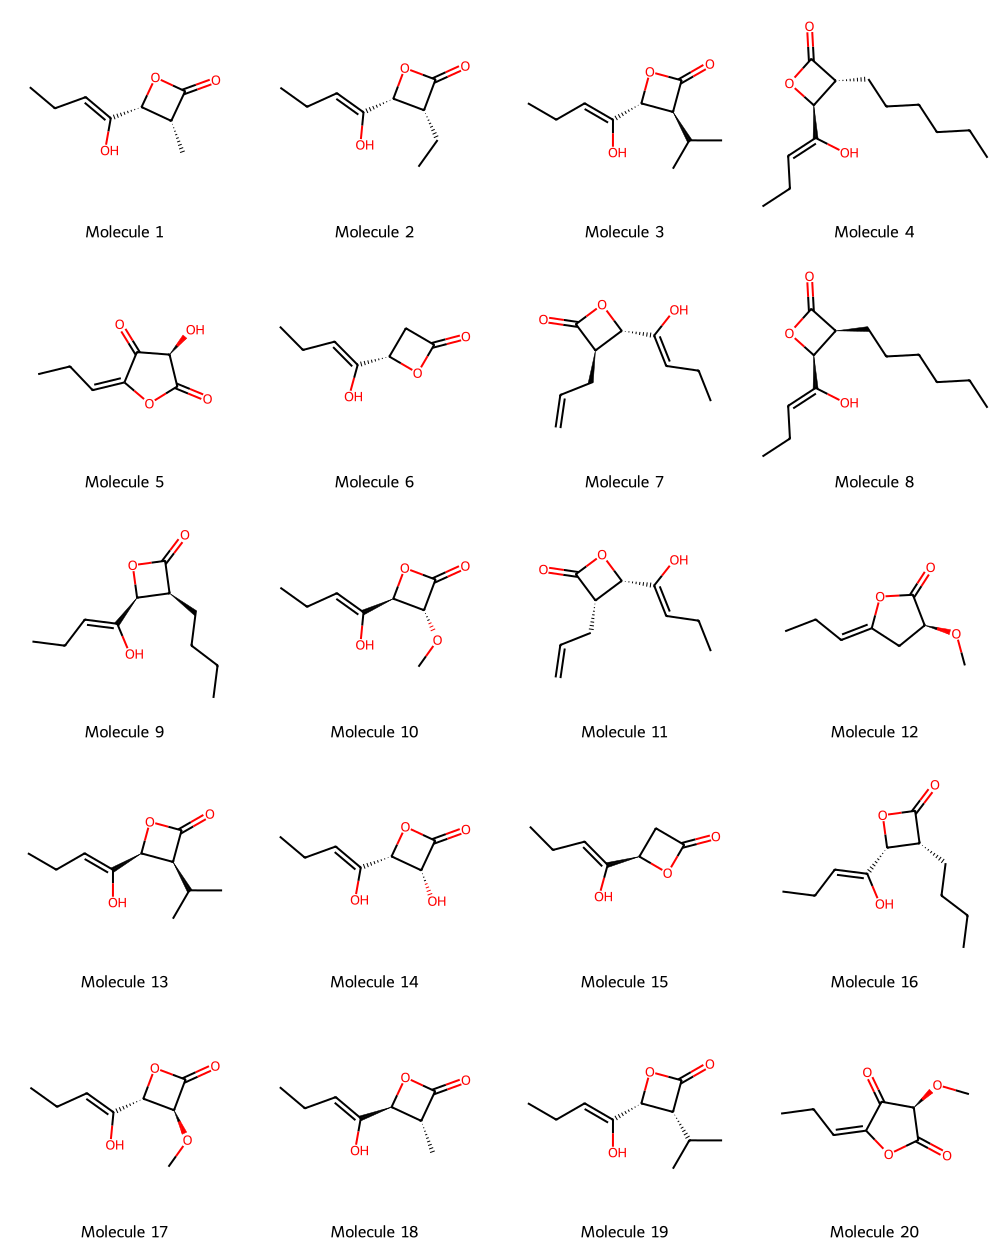

In [69]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES back to molecules for visualization
mols = [Chem.MolFromSmiles(smiles) for smiles in generated_molecules_diverseStarterSeocndExtension['Canonical_SMILES'].head(20)]

# Create a grid of molecules
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 250),
                           legends=[f"Molecule {i+1}" for i in range(len(mols))])
display(img)

### Diversify molecules
1. Keep fixed module1
2. diversify only starter and second extension module
3. The TE domain is trying to cyclize the molecule, but the chemical reaction pattern doesn't match the molecule structure, so rxn.RunReactants() returns an empty result with 73.6% failure rate. So we are using different ring positionsto find most diverse set of molecules.

In [71]:
%%time

from rdkit import Chem
from rdkit.Chem import Descriptors
from collections import OrderedDict
import pandas as pd

# Extract Module objects from structureDB keys
allModules = list(structureDB.keys())

print("Number of unique designs in module:", len(allModules))
print(f"Maximum possible combinations: {len(allModules)} starters × {len(allModules)} second extensions = {len(allModules) * len(allModules)}")

results = []

# Track failures and ring usage
failure_reasons = {
    'no_product_from_computeProduct': 0,
    'all_TE_attempts_failed': 0,
    'exception_errors': 0
}

ring_usage = {}  # Track which ring positions worked

print(f"\nCreating diverse molecules with variable starter and module2...")
print(f"Trying multiple ring positions to maximize success\n")

# Fixed components (module1 only)
AT_domain_mod1 = bcs.AT(active=True, substrate="hmal") 
KR_domain_mod1 = bcs.KR(active=True, type="B1")
DH_domain_mod1 = bcs.DH(active=True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})
module1 = bcs.Module(domains=mod1_domains_dict, loading=False)

# Fixed descriptions
first_extension_description = "AT(hmal) + KR(B1) + DH"

# Define ring positions to try (adjust range based on your molecule size)
ring_positions_to_try = [1, 2, 3, 4, 5]  # Try different ring positions

# Nested loop: iterate through all starter and second extension combinations
total_combinations = len(allModules) * len(allModules)
processed = 0

for starter_idx, starter_module in enumerate(allModules):
    # Create loading module from starter_module domains
    loading_module = bcs.Module(domains=starter_module.domains, loading=True)
    starter_description = str(starter_module)
    
    for mod2_idx, module2 in enumerate(allModules):
        processed += 1
        
        try:
            # Create cluster with variable starter, fixed module1, and variable module2
            cluster = bcs.Cluster(modules=[loading_module, module1, module2])
            mol = cluster.computeProduct(structureDB)
            
            if mol:
                # Try different ring positions until one works
                final_mol = None
                successful_ring = None
                
                for ring_pos in ring_positions_to_try:
                    try:
                        myTEobject = bcs.TE(active=True, cyclic=True, ring=ring_pos)
                        temp_mol = myTEobject.operation(mol)
                        
                        if temp_mol:
                            final_mol = temp_mol
                            successful_ring = ring_pos
                            break  # Found a working ring position
                    except:
                        continue  # Try next ring position
                
                if final_mol:
                    smiles = Chem.MolToSmiles(final_mol, canonical=True)
                    
                    # Calculate molecular weight
                    mol_obj = Chem.MolFromSmiles(smiles)
                    mol_weight = Descriptors.MolWt(mol_obj) if mol_obj else None
                    
                    # Create description for module2
                    module2_description = str(module2)
                    release_description = f"TE(cyclic, ring={successful_ring})"
                    
                    # Track ring usage
                    ring_usage[successful_ring] = ring_usage.get(successful_ring, 0) + 1
                    
                    results.append({
                        'Canonical_SMILES': smiles,
                        'starter_mod': starter_description,
                        'firstExtension_module': first_extension_description,
                        'secondExtension_mod': module2_description,
                        'release_mod': release_description,
                        'ring_position': successful_ring,
                        'Molecular_Weight': round(mol_weight, 2) if mol_weight else None
                    })
                else:
                    # All ring positions failed
                    failure_reasons['all_TE_attempts_failed'] += 1
            else:
                # computeProduct returned None
                failure_reasons['no_product_from_computeProduct'] += 1
                    
            if processed % 1000 == 0:
                print(f"Processed {processed}/{total_combinations} combinations ({100*processed/total_combinations:.1f}%)...")
                        
        except Exception as e:
            failure_reasons['exception_errors'] += 1
            if failure_reasons['exception_errors'] <= 3:
                import traceback
                print(f"\nException for combination (starter={starter_idx}, mod2={mod2_idx}):")
                traceback.print_exc()
            continue

# Create DataFrame
generated_molecules_diverseStarterSeocndExtensionMultiRing = pd.DataFrame(results, columns=[
    'Canonical_SMILES',
    'starter_mod',
    'firstExtension_module',
    'secondExtension_mod',
    'release_mod',
    'ring_position',
    'Molecular_Weight'
])

print("Summary:")
print(f"Total molecules generated: {len(generated_molecules_diverseStarterSeocndExtensionMultiRing)}")
print(f"Success rate: {len(generated_molecules_diverseStarterSeocndExtensionMultiRing)}/{total_combinations} ({100*len(generated_molecules_diverseStarterSeocndExtensionMultiRing)/total_combinations:.1f}%)")


print("\nFailed combinations:")
successful = len(generated_molecules_diverseStarterSeocndExtensionMultiRing)
total_failed = total_combinations - successful

for reason, count in failure_reasons.items():
    percentage = (count/total_combinations)*100 if total_combinations > 0 else 0
    print(f"  {reason}: {count} ({percentage:.1f}%)")

print(f"\nTotal successful: {successful} ({100*successful/total_combinations:.1f}%)")
print(f"Total failed: {total_failed} ({100*total_failed/total_combinations:.1f}%)")


print("Diversification due to modified ring positions:")
for ring_pos in sorted(ring_usage.keys()):
    count = ring_usage[ring_pos]
    print(f"  Ring position {ring_pos}: {count} molecules ({100*count/successful:.1f}%)")

# Drop duplicate SMILES
original_count = len(generated_molecules_diverseStarterSeocndExtensionMultiRing)
generated_molecules_diverseStarterSeocndExtensionMultiRing = generated_molecules_diverseStarterSeocndExtensionMultiRing.drop_duplicates(subset=['Canonical_SMILES'], keep='first')
print(f"Molecules before deduplication: {original_count}")
print(f"Unique molecules after removing duplicates: {len(generated_molecules_diverseStarterSeocndExtensionMultiRing)}")
print(f"Duplicates removed: {original_count - len(generated_molecules_diverseStarterSeocndExtensionMultiRing)} ({100*(original_count - len(generated_molecules_diverseStarterSeocndExtensionMultiRing))/original_count:.1f}%)")

# Save to CSV
generated_molecules_diverseStarterSeocndExtensionMultiRing.to_csv('generated_molecules_diverseStarterSeocndExtensionMultiRing.csv', index=False)
print("\nSaved to 'generated_molecules_diverseStarterSeocndExtensionMultiRing.csv'")
generated_molecules_diverseStarterSeocndExtensionMultiRing

Number of unique designs in module: 95
Maximum possible combinations: 95 starters × 95 second extensions = 9025

Creating diverse molecules with variable starter and module2...
Trying multiple ring positions to maximize success


Exception for combination (starter=1, mod2=0):

Exception for combination (starter=1, mod2=1):

Exception for combination (starter=1, mod2=2):


Traceback (most recent call last):
  File "<timed exec>", line 56, in <module>
  File "/usr/local/lib/python3.12/site-packages/bcs/bcs.py", line 192, in computeProduct
    prod = starters[module.domains[AT].substrate]
           ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyError: 'emal'
Traceback (most recent call last):
  File "<timed exec>", line 56, in <module>
  File "/usr/local/lib/python3.12/site-packages/bcs/bcs.py", line 192, in computeProduct
    prod = starters[module.domains[AT].substrate]
           ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyError: 'emal'
Traceback (most recent call last):
  File "<timed exec>", line 56, in <module>
  File "/usr/local/lib/python3.12/site-packages/bcs/bcs.py", line 192, in computeProduct
    prod = starters[module.domains[AT].substrate]
           ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyError: 'emal'


Processed 2000/9025 combinations (22.2%)...
Processed 3000/9025 combinations (33.2%)...
Processed 4000/9025 combinations (44.3%)...
Processed 6000/9025 combinations (66.5%)...
Processed 8000/9025 combinations (88.6%)...
Summary:
Total molecules generated: 2455
Success rate: 2455/9025 (27.2%)

Failed combinations:
  no_product_from_computeProduct: 0 (0.0%)
  all_TE_attempts_failed: 1440 (16.0%)
  exception_errors: 5130 (56.8%)

Total successful: 2455 (27.2%)
Total failed: 6570 (72.8%)
Diversification due to modified ring positions:
  Ring position 1: 2383 molecules (97.1%)
  Ring position 2: 72 molecules (2.9%)
Molecules before deduplication: 2455
Unique molecules after removing duplicates: 259
Duplicates removed: 2196 (89.5%)

Saved to 'generated_molecules_diverseStarterSeocndExtensionMultiRing.csv'
CPU times: user 1.74 s, sys: 0 ns, total: 1.74 s
Wall time: 1.74 s


,Canonical_SMILES,starter_mod,firstExtension_module,secondExtension_mod,release_mod,ring_position,Molecular_Weight
0,CCC=C(O)[C@@H]1OC(=O)[C@@H]1C,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...","TE(cyclic, ring=1)",1,156.18
1,CCC=C(O)[C@@H]1OC(=O)[C@@H]1CC,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'A1'}""...","TE(cyclic, ring=1)",1,170.21
2,CCC=C(O)[C@@H]1OC(=O)[C@H]1C(C)C,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'isobutmal'}"", ""KR{'type': '...","TE(cyclic, ring=1)",1,184.23
4,CCC=C(O)[C@H]1OC(=O)[C@@H]1CCCCCC,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'B1'...","TE(cyclic, ring=1)",1,226.32
5,CCC=C1OC(=O)[C@H](O)C1=O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hmal'}"", ""KR{'type': 'C1'}""...","TE(cyclic, ring=1)",1,156.14
...,...,...,...,...,...,...,...
1364,O=C1O[C@@H](C(O)=Cc2c[nH]c(Cl)c2Cl)[C@H]1CCCCc...,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'C2'}"",...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'A1'}"",...","TE(cyclic, ring=1)",1,438.14
1366,O=C1O[C@@H](C(O)=Cc2c[nH]c(Cl)c2Cl)[C@@H]1O,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'C2'}"",...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hmal'}"", ""KR{'type': 'A2'}""...","TE(cyclic, ring=1)",1,264.06
1367,CCCC[C@@H]1C(=O)O[C@H]1C(O)=Cc1c[nH]c(Cl)c1Cl,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'C2'}"",...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'butmal'}"", ""KR{'type': 'A2'...","TE(cyclic, ring=1)",1,304.17
1368,CCCCCC[C@@H]1C(=O)O[C@H]1C(O)=Cc1c[nH]c(Cl)c1Cl,"[""AT{'substrate': 'DCP'}"", ""KR{'type': 'C2'}"",...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'A2'...","TE(cyclic, ring=1)",1,332.23


### Display molecules

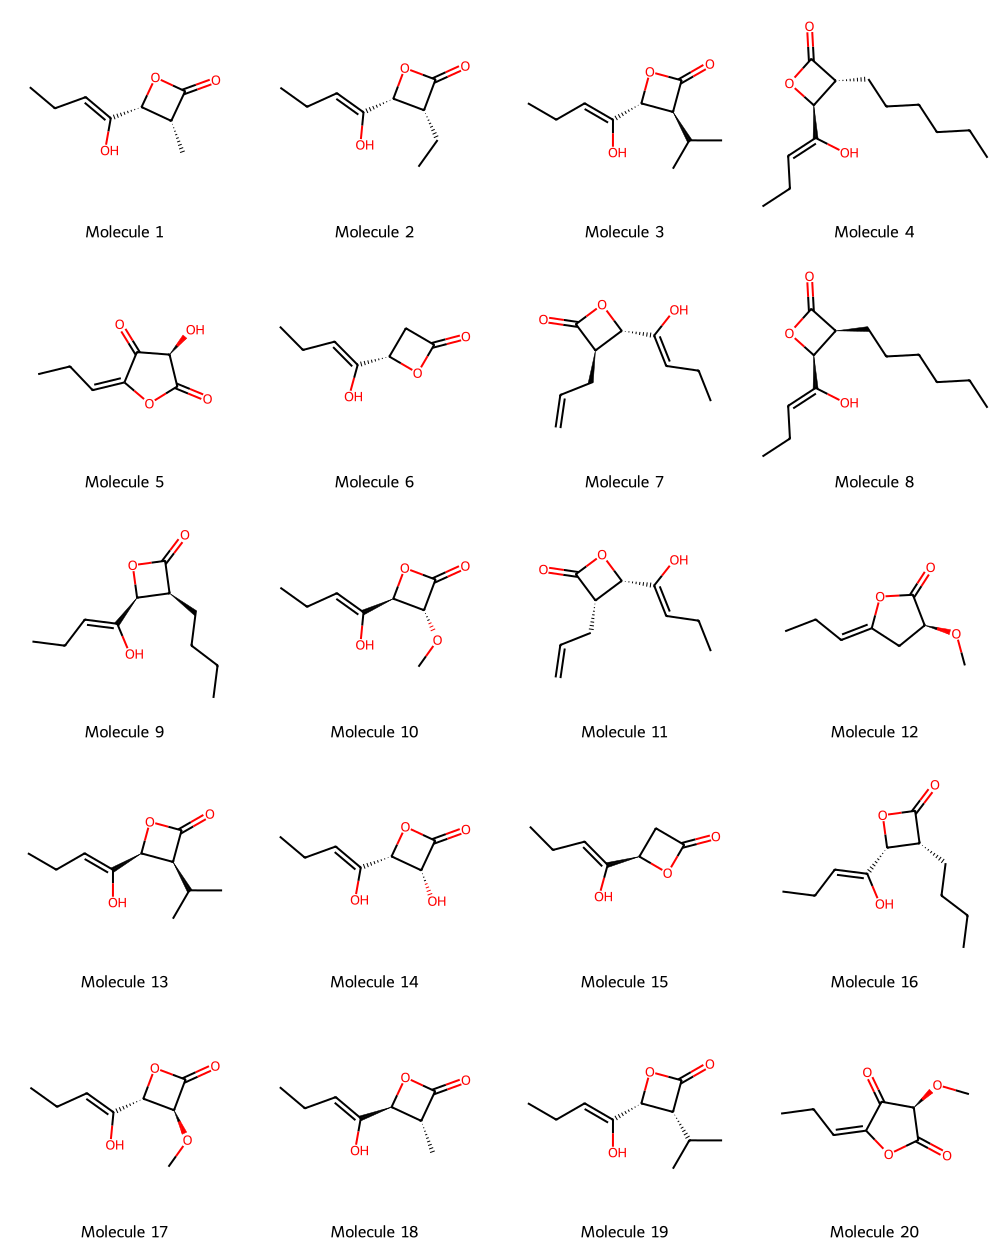

In [72]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES back to molecules for visualization
mols = [Chem.MolFromSmiles(smiles) for smiles in generated_molecules_diverseStarterSeocndExtensionMultiRing['Canonical_SMILES'].head(20)]

# Create a grid of molecules
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 250),
                           legends=[f"Molecule {i+1}" for i in range(len(mols))])
display(img)